## Import Libraries

In [84]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [85]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [86]:
df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Missing values

In [87]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [88]:
df.duplicated().sum()

df.drop_duplicates(inplace=True)

## EDA

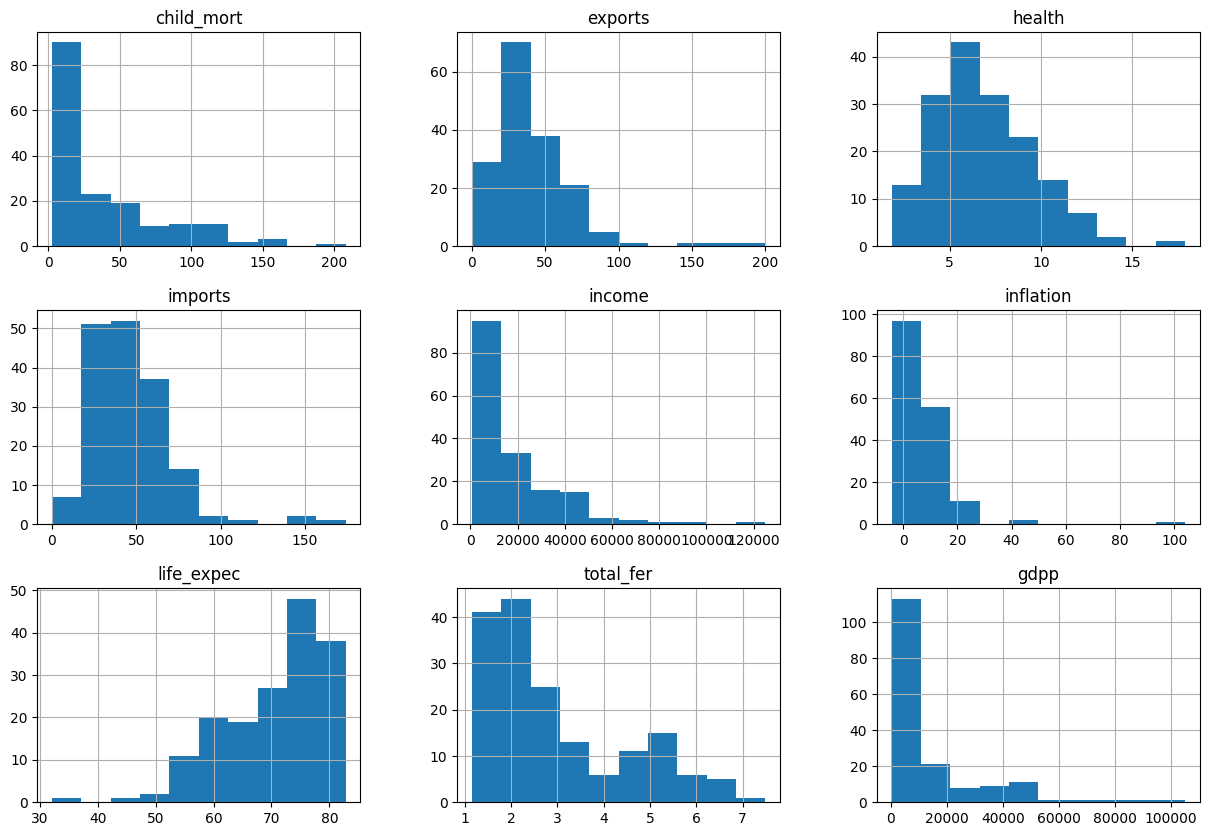

In [89]:
df.hist(figsize=(15,10))
plt.show()

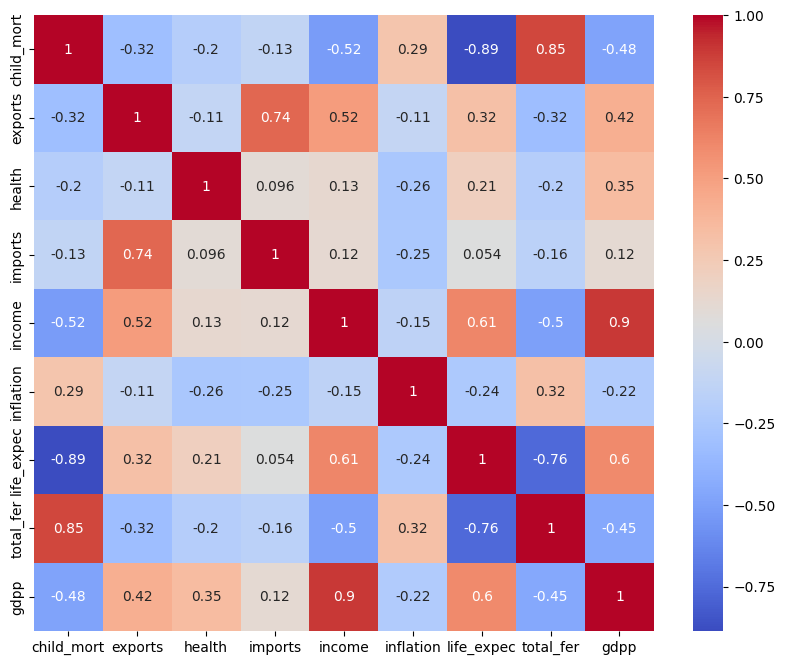

In [90]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("country",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

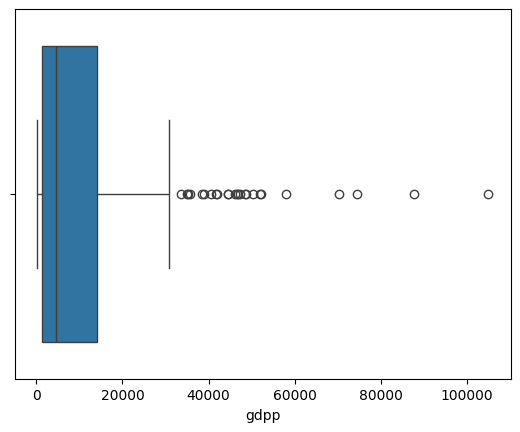

In [91]:
sns.boxplot(x=df["gdpp"])
plt.show()

## Feature scaling

In [92]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df.drop("country", axis=1)
)

## PCA

In [93]:
pca = PCA(n_components=2, random_state=42)

pca_data = pca.fit_transform(X_scaled)

## elbow method

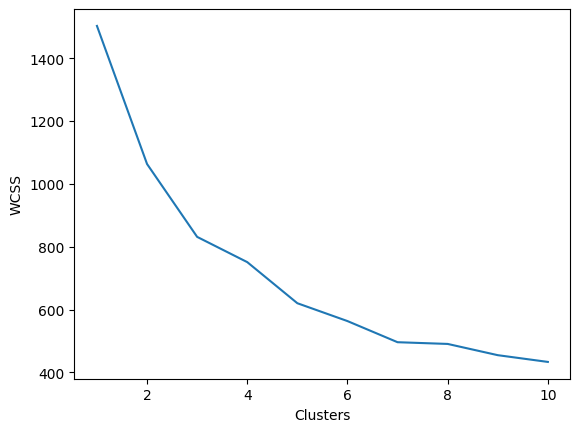

In [94]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

## K means

In [95]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(pca_data)

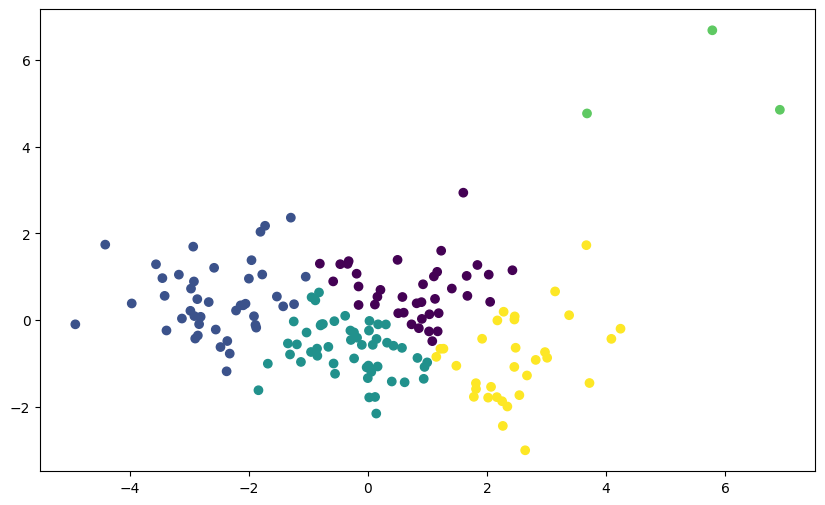

In [96]:
plt.figure(figsize=(10,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"]
)

plt.show()

In [97]:
df.groupby("Cluster").mean(
    numeric_only=True
)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,17.534211,58.697368,6.090263,63.818421,17031.842105,4.963342,73.468421,2.185789,8973.315789
1,96.802326,28.988605,6.142093,42.939535,3394.023256,12.335930,59.037209,5.135814,1666.488372
2,27.149020,28.439000,6.427255,36.015018,10062.941176,9.828549,71.507843,2.499216,5109.196078
3,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667
4,5.165625,44.056250,9.203437,39.137500,42646.875000,2.245437,80.037500,1.775313,41221.875000


In [98]:
df["Development_Status"] = df["Cluster"]

## Encode Target

In [99]:
X = df.drop(
    [
        "country",
        "Cluster",
        "Development_Status"
    ],
    axis=1
)

y = df["Development_Status"]

In [100]:
X = df.drop(
    ["country","Cluster","Development_Status"],
    axis=1
)

y = df["Development_Status"]

In [101]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Train_test_split

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scale for models

In [103]:
feature_scaler = StandardScaler()

X_train = feature_scaler.fit_transform(X_train)
X_test = feature_scaler.transform(X_test)

## Logistic Regression

In [104]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Accuracy:", lr_acc)

Logistic Accuracy: 0.9117647058823529


## KNN

In [105]:
knn = KNeighborsClassifier(
    n_neighbors=7
)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.8529411764705882


## Random Forest

In [106]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("RF Accuracy:", rf_acc)

RF Accuracy: 0.8529411764705882


## XGBOOST

In [107]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGB Accuracy:", xgb_acc)

XGB Accuracy: 0.8529411764705882


## Ensemble Techniques

In [108]:
ensemble = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb)
    ],
    voting="soft"
)

ensemble.fit(X_train, y_train)

ensemble_pred = ensemble.predict(X_test)

ensemble_acc = accuracy_score(
    y_test,
    ensemble_pred
)

print("Ensemble Accuracy:", ensemble_acc)

Ensemble Accuracy: 0.8823529411764706


## Model Comparision

In [109]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "XGBoost",
        "Ensemble"
    ],
    "Accuracy":[
        lr_acc,
        knn_acc,
        rf_acc,
        xgb_acc,
        ensemble_acc
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)
print(results)

                 Model  Accuracy
0  Logistic Regression  0.911765
1                  KNN  0.852941
2        Random Forest  0.852941
3              XGBoost  0.852941
4             Ensemble  0.882353


In [110]:
manual_country = pd.DataFrame({

'child_mort':[20],
'exports':[35],
'health':[6],
'imports':[40],
'income':[12000],
'inflation':[5],
'life_expec':[75],
'total_fer':[2.1],
'gdpp':[10000],
'Cluster':[1]

})

In [111]:
manual_country_processed = manual_country.drop('Cluster', axis=1)
scaled_manual_country = feature_scaler.transform(manual_country_processed)

prediction = ensemble.predict(
    scaled_manual_country
)

# The target variable 'Development_Status' was assigned directly from 'Cluster' (numeric values),
# not encoded with LabelEncoder. So, inverse_transform is not needed and 'le' is not defined.
status = prediction

print(status)

[2]
